In [1]:
import sys
sys.path.append('../')
import UTILS.utils as utils

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import decomposition
import pandas as pd
import re
import spacy
import gensim
from itertools import combinations
from top2vec import Top2Vec

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import gensim.corpora as corpora
from gensim.models import CoherenceModel
from tqdm import tqdm

## TOPIC MODELLING WITH TOP2VEC

In [2]:
min_cluster_size = [5, 10, 15, 20]
n_neighbors = [10, 15, 20, 30]
models = ["doc2vec", "universal-sentence-encoder-large", "all-MiniLM-L6-v2", "paraphrase-multilingual-MiniLM-L12-v2"]

params = [(x, y, z) for x in min_cluster_size for y in n_neighbors for z in models]

In [3]:
def test_hyperparams(documents, corpus, tokenized, id2word):
    all_rows = []
    for param in tqdm(params):
        cluster_size = param[0]
        n_neighbors = param[1]
        model = param[2]
        topic_model = Top2Vec(
            documents,
            contextual_top2vec=False,
            speed="deep-learn",
            embedding_model=model,
            hdbscan_args={"min_cluster_size": cluster_size},
            umap_args={"n_neighbors": n_neighbors, "random_state": 100},
            ngram_vocab_args={"connector_words": "phrases.ENGLISH_CONNECTOR_WORDS"},
        )
        num_topics = topic_model.get_num_topics()
        topic_words, _, topic_nums = topic_model.get_topics(num_topics=num_topics)
        cm = CoherenceModel(topics=[s.tolist() for s in topic_words] ,texts=tokenized
                    , corpus=corpus, dictionary=id2word, coherence='c_v')
        this_row = [cluster_size, n_neighbors, model, num_topics, cm.get_coherence()]
        all_rows.append(this_row)
    return all_rows

### SENTENCES

In [4]:
all_sentences = pd.read_csv(utils.ALL_SENTENCES_DF)
df = pd.DataFrame(all_sentences, columns=["text"])
train_data = [s.lower() for s in df["text"].to_list()]

In [5]:
from gensim.utils import tokenize

tokenized = [list(tokenize(s)) for s in train_data]
id2word = corpora.Dictionary(tokenized)
corpus = [id2word.doc2bow(text) for text in tokenized]

In [ ]:
hyperparams = test_hyperparams(train_data, corpus, tokenized, id2word)
hyperparams_df = pd.DataFrame(hyperparams, columns=["min_cluster_size", "n_neighbors", "model", "num_topics", "coherence"])
hyperparams_df.to_csv("../Data/HYPERPARAMS/TOP2VEC_sentences.csv")

In [10]:
hyperparams_df = pd.read_csv("../../Data/HYPERPARAMS/TOP2VEC_sentences.csv")

In [11]:
def enough_topics(x):
    return x >= 10 and x <= 30

# test for enough topics
filtered_df = hyperparams_df[hyperparams_df["num_topics"].apply(lambda x : enough_topics(x))]
maxidx = filtered_df[["coherence"]].idxmax()
hyperparams_df.iloc[maxidx]

,Unnamed: 0,min_cluster_size,n_neighbors,model,num_topics,coherence
32,32,15,10,doc2vec,13,0.485225


In [24]:
topic_model = Top2Vec(
            train_data,
            contextual_top2vec=False,
            speed="deep-learn",
            embedding_model="doc2vec",
            hdbscan_args={"min_cluster_size": 10},
            umap_args={"n_neighbors": 15, "random_state": 100},
            ngram_vocab_args={"connector_words": "phrases.ENGLISH_CONNECTOR_WORDS"},
        )

2025-06-24 17:35:31,576 - top2vec - INFO - Pre-processing documents for training
2025-06-24 17:35:31,667 - top2vec - INFO - Creating joint document/word embedding
2025-06-24 17:35:58,516 - top2vec - INFO - Creating lower dimension embedding of documents
/Users/emmanuelle/Desktop/PDM/Moonchu/pdm/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/emmanuelle/Desktop/PDM/Moonchu/pdm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2025-06-24 17:36:05,763 - top2vec - INFO - Finding dense areas of documents
/Users/emmanuelle/Desktop/PDM/Moonchu/pdm/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/emmanuelle/Des

In [1]:
s = """Topic 0: right, legation, imperial, wall, along, north, point, gate, street, west, building, distance, mile, south, side, again, now, toward, left, stand, city, look, river, lines, map, our, near, shall, first, line, we, red, buildings, half, which, english, view, on, between, through, see, number, native, where, over, another, from, its, then, way
Topic 1: tien, tsin, during, after, day, boat, night, pekin, out, made, by, several, away, then, being, from, had, down, miles, again, us, was, now, first, house, through, large, under, before, over, for, where, its, view, at, the, into, with, place, our, legation, little, native, great, same, west, another, to, find, on
Topic 2: map, red, lines, number, position, line, north, toward, find, west, south, right, our, half, imperial, wall, city, gate, left, between, mile, point, from, near, distance, legation, river, pekin, its, now, which, look, native, we, building, street, buildings, first, two, see, view, over, on, away, english, way, again, shall, side, american
Topic 3: being, my, was, day, most, under, for, much, other, had, when, down, tea, these, it, several, before, after, up, made, me, but, place, so, only, while, large, small, this, out, time, night, little, any, boat, all, were, some, hundred, with, been, china, during, who, found, to, as, tien, by, and
Topic 4: he, him, his, me, time, my, found, who, out, had, upon, but, could, was, for, day, has, when, very, an, after, tea, would, been, while, under, not, few, if, in, that, as, place, well, up, to, no, most, only, into, were, being, some, house, several, made, any, she, with, it
Topic 5: so, more, it, much, these, other, than, any, small, being, world, for, tea, them, may, people, large, seen, feet, most, that, many, as, is, but, every, hundred, china, there, even, all, one, made, are, an, this, have, called, of, at, before, or, little, down, building, only, and, be, they, about
Topic 6: they, seen, these, them, much, most, do, so, their, even, are, any, but, not, some, people, how, as, have, may, such, what, me, more, also, many, when, long, it, same, could, those, in, would, world, than, can, for, you, who, no, upon, little, here, boats, small, were, an, been, there
Topic 7: also, seen, they, their, way, them, but, same, called, court, how, those, along, other, so, some, are, have, buildings, position, any, near, place, between, river, on, look, may, here, many, see, as, that, these, with, lines, for, in, of, chinese, much, very, all, now, boats, this, you, large, no, can
Topic 8: river, down, along, again, street, view, building, here, buildings, right, being, this, before, little, large, other, great, our, now, imperial, side, over, near, city, distance, where, mile, stand, called, miles, three, small, its, within, point, on, legation, made, of, seen, see, is, first, up, from, shall, through, us, same, hundred
Topic 9: more, so, even, there, she, if, very, any, be, than, world, many, do, has, her, people, such, well, years, china, not, them, or, it, much, who, time, that, upon, they, most, is, day, foreign, tea, for, but, could, an, may, no, have, under, men, their, all, as, long, seen, him
Topic 10: west, red, map, wall, city, imperial, distance, pekin, legation, gate, south, north, mile, lines, miles, left, half, line, five, right, street, first, over, tsin, between, toward, tien, within, number, position, shall, three, native, point, feet, side, building, view, hundred, two, its, along, american, stand, find, look, from, which, away, see
Topic 11: she, her, if, very, upon, who, me, even, must, well, has, foreign, would, men, he, time, an, my, while, back, be, can, feet, in, house, to, people, years, him, about, his, their, not, do, it, any, at, when, so, long, than, been, or, american, this, that, and, stand, only, what
Topic 12: they, even, do, seen, if, them, any, so, such, their, not, upon, most, these, much, would, be, me, than, people, have, but, more, what, could, are, as, many, some, men, how, also, may, can, it, well, in, who, she, here, you, there, time, very, little, must, no, long, when, or
Topic 13: do, they, them, their, seen, not, are, many, but, no, these, such, any, so, as, those, have, much, may, people, how, most, even, some, also, what, there, more, than, you, could, upon, in, can, time, be, long, boats, well, for, world, all, years, men, will, who, it, same, if, would
Topic 14: any, so, but, who, years, people, much, even, for, time, me, it, such, many, tea, only, being, under, as, china, most, made, have, day, there, seen, not, my, them, all, foreign, be, other, when, these, than, very, hundred, an, world, that, has, well, do, are, would, if, this, in, little
Topic 15: day, me, found, could, him, my, he, was, were, had, long, much, after, when, who, time, into, his, place, upon, an, but, would, out, for, as, during, to, while, american, several, that, been, not, what, it, by, way, same, their, some, up, with, so, in, made, another, from, even, and
Topic 16: look, shall, along, will, here, stand, we, river, now, point, wall, can, little, seen, distance, view, right, see, those, imperial, way, called, buildings, mile, legation, few, gate, how, you, they, us, our, also, side, if, left, again, among, great, where, down, near, while, toward, on, north, building, of, street, english
Topic 17: boat, out, had, into, again, he, under, back, after, map, my, up, him, house, on, his, another, among, number, english, through, before, away, with, we, us, right, few, way, court, find, tea, was, near, very, now, at, then, for, were, first, from, several, been, found, lines, red, our, pekin, day
Topic 18: being, other, much, under, these, there, for, seen, night, many, most, any, during, so, china, day, small, all, them, than, large, it, are, made, same, may, only, have, but, more, hundred, this, such, within, three, world, as, tea, their, even, they, is, that, before, down, people, when, at, little, five
Topic 19: any, seen, do, there, have, such, people, tea, china, are, no, many, they, even, than, men, them, their, very, but, not, these, be, of, if, other, is, so, world, view, more, may, can, as, few, an, here, or, in, could, some, for, those, great, what, much, it, small, find, boats
Topic 20: day, he, who, would, was, an, me, so, my, long, for, it, much, could, but, what, time, while, his, made, him, tea, very, feet, years, being, had, boat, that, after, upon, several, some, as, under, be, china, to, world, even, this, if, other, in, only, foreign, by, has, not, found
Topic 21: years, five, hundred, so, tea, china, people, made, long, well, such, feet, an, would, three, about, only, one, it, being, time, world, who, any, while, among, at, be, very, some, of, two, over, for, few, that, in, or, little, miles, but, than, what, even, more, have, them, and, if, great
Topic 22: tea, feet, if, china, than, only, she, or, her, even, more, who, world, small, is, about, hundred, at, great, time, people, there, any, an, would, while, one, being, can, three, when, it, so, are, well, little, upon, not, among, that, where, miles, to, this, no, made, out, for, found, them
Topic 23: well, upon, be, their, she, much, long, among, how, court, were, half, men, also, that, every, as, her, into, about, them, at, these, so, must, it, an, they, night, more, those, could, even, made, many, very, little, under, look, all, of, than, can, up, found, feet, have, do, most, such
Topic 24: do, buildings, how, will, are, may, seen, they, there, you, right, many, them, court, river, along, those, near, lines, also, see, down, water, boats, here, street, point, now, is, shall, called, building, great, night, look, south, where, imperial, english, north, within, or, no, world, not, city, same, toward, their, what
Topic 25: there, has, be, every, than, seen, well, all, many, it, as, how, people, an, tea, is, so, that, them, men, no, any, more, very, her, or, been, also, what, are, up, great, upon, but, of, court, world, under, large, china, even, among, for, here, most, other, she, they, these, only"""

In [7]:
l = s.split("\n")
for x in l:
    x = x.split(":")[1].strip()
    x = ",".join(x.split(",")[:8])
    s = "\item" + "\\" + "v" + "space{-0.2cm}["
    print(s + x + "]")
    

\item\vspace{-0.2cm}[right, legation, imperial, wall, along, north, point, gate]
\item\vspace{-0.2cm}[tien, tsin, during, after, day, boat, night, pekin]
\item\vspace{-0.2cm}[map, red, lines, number, position, line, north, toward]
\item\vspace{-0.2cm}[being, my, was, day, most, under, for, much]
\item\vspace{-0.2cm}[he, him, his, me, time, my, found, who]
\item\vspace{-0.2cm}[so, more, it, much, these, other, than, any]
\item\vspace{-0.2cm}[they, seen, these, them, much, most, do, so]
\item\vspace{-0.2cm}[also, seen, they, their, way, them, but, same]
\item\vspace{-0.2cm}[river, down, along, again, street, view, building, here]
\item\vspace{-0.2cm}[more, so, even, there, she, if, very, any]
\item\vspace{-0.2cm}[west, red, map, wall, city, imperial, distance, pekin]
\item\vspace{-0.2cm}[she, her, if, very, upon, who, me, even]
\item\vspace{-0.2cm}[they, even, do, seen, if, them, any, so]
\item\vspace{-0.2cm}[do, they, them, their, seen, not, are, many]
\item\vspace{-0.2cm}[any, so, but,

<>:5: SyntaxWarning: invalid escape sequence '\i'
<>:5: SyntaxWarning: invalid escape sequence '\i'
/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_85661/2680279721.py:5: SyntaxWarning: invalid escape sequence '\i'
  s = "\item" + "\\" + "v" + "space{-0.2cm}["


In [26]:
topic_words, _, topic_nums = topic_model.get_topics(num_topics=26)

for idx, words in enumerate(topic_words):
    print(f"Topic {topic_nums[idx]}: {', '.join(words)}")

Topic 0: right, legation, imperial, wall, along, north, point, gate, street, west, building, distance, mile, south, side, again, now, toward, left, stand, city, look, river, lines, map, our, near, shall, first, line, we, red, buildings, half, which, english, view, on, between, through, see, number, native, where, over, another, from, its, then, way
Topic 1: tien, tsin, during, after, day, boat, night, pekin, out, made, by, several, away, then, being, from, had, down, miles, again, us, was, now, first, house, through, large, under, before, over, for, where, its, view, at, the, into, with, place, our, legation, little, native, great, same, west, another, to, find, on
Topic 2: map, red, lines, number, position, line, north, toward, find, west, south, right, our, half, imperial, wall, city, gate, left, between, mile, point, from, near, distance, legation, river, pekin, its, now, which, look, native, we, building, street, buildings, first, two, see, view, over, on, away, english, way, again

In [37]:
doc_topics, topic_docs_scores, x, y = topic_model.get_documents_topics(doc_ids=list(range(len(all_sentences))))
topic_counts = pd.Series(doc_topics).value_counts()
topic_counts_sorted = topic_counts.sort_values(ascending=False)
df_plot = topic_counts_sorted.reset_index()
df_plot.columns = ['Topic', 'Number of Documents']
df_plot['Topic'] = df_plot['Topic'].apply(lambda x: f"{x}")


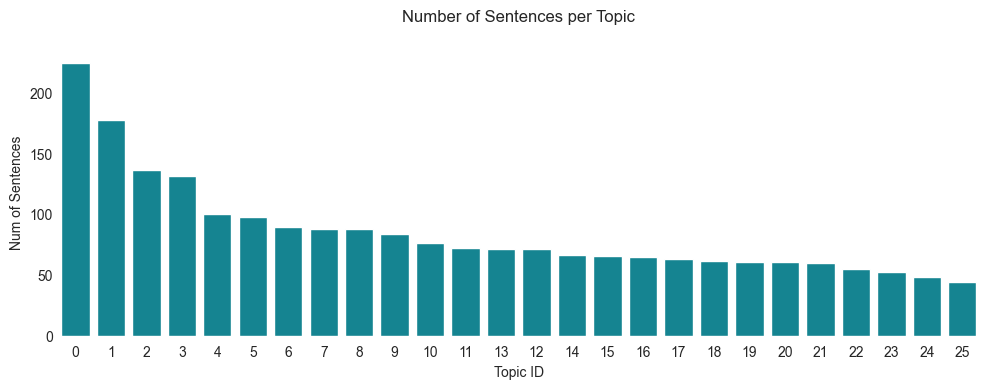

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

sns.set_style("white") 
plt.figure(figsize=(10, 4)) 

ax = sns.barplot(x='Topic', y='Number of Documents', data=df_plot,
                 #order=topic_order,
                 color='#0094a6') 

plt.xlabel('Topic ID') 
sns.despine(left=True, bottom=True, top=True, right=True)
ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
plt.ylabel('Num of Sentences')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.title('Number of Sentences per Topic', pad=20)

plt.tight_layout()
plt.show()

### PARAGRAPHS

In [ ]:
all_paragraphs = pd.read_csv("../../Data/TEXT/ALL_PARAGRAPHS.csv")
df_paragraph = pd.DataFrame(all_paragraphs, columns=["text"])
train_data_paragraph = [s.lower() for s in df_paragraph["text"].to_list()]

In [7]:
from gensim.utils import tokenize

tokenized_paragraphs = [list(tokenize(s)) for s in train_data_paragraph]
id2word_paragraphs = corpora.Dictionary(tokenized_paragraphs)
corpus_paragraphs = [id2word_paragraphs.doc2bow(text) for text in tokenized_paragraphs]

In [ ]:
hyperparams_paragraph = test_hyperparams(train_data_paragraph,corpus_paragraphs,tokenized_paragraphs, id2word_paragraphs )
hyperparams_df = pd.DataFrame(hyperparams_paragraph, columns=["min_cluster_size", "n_neighbors", "model", "num_topics", "coherence"])
hyperparams_df.to_csv("../../Data/HYPERPARAMS/TOP2VEC_paragraphs.csv")

In [15]:
hyperparams_df = pd.read_csv("../../Data/HYPERPARAMS/TOP2VEC_paragraphs.csv")
filtered_df = hyperparams_df[hyperparams_df["num_topics"].apply(lambda x : enough_topics(x))]
maxidx = filtered_df[["coherence"]].idxmax()
hyperparams_df.iloc[maxidx]

,Unnamed: 0,min_cluster_size,n_neighbors,model,num_topics,contextual,coherence
0,0,5,10,doc2vec,21,False,0.440004
